# 05 — Evaluation, post-processing, and ablation study

## What this notebook does

1. Loads outputs from NB03 (full-gene) and NB04 (gene-subset).
2. Computes calibrated confidence scores and flags low-confidence cells.
3. Adds a new "subset-driven" flagging criterion using the NB04 subset predictions.
4. Runs five re-segmentation experiments (ablation configurations).
5. Reports which cells improved and by how much.
6. Generates spatial confidence maps and example corrected-cell figures.
7. Summarises results for the final report.

**Inputs** (from NB02, NB03, NB04)
- `outputs/cell_expression_aligned.csv`
- `outputs/prototypes_normalized.csv`
- `outputs/cell_type_predictions.csv`
- `outputs/cosine_similarity_matrix.csv`
- `outputs/assigned_transcripts_crop.csv`
- `outputs/cell_type_predictions_marker_subset.csv`   ← from NB04
- `outputs/cosine_similarity_matrix_marker_subset.csv` ← from NB04
- `data/masks_center.npy`

**Outputs**
- `outputs/cell_type_predictions_refined_best.csv`
- `outputs/ablation_all_cell_results.csv`
- `outputs/ablation_experiment_metrics.csv`
- `outputs/final_ablation_summary_table.csv`
- `outputs/figures/confidence_map.png`
- `outputs/figures/ablation_experiment_summary.png`
- `outputs/figures/gene_subset_vs_fullgene_confidence.png`


## Imports

In [1]:
from pathlib import Path
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile as tiff

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

try:
    from cellpose import models
    CELLPOSE_AVAILABLE = True
except Exception as e:
    CELLPOSE_AVAILABLE = False
    print("Cellpose import failed. Re-segmentation experiments will be skipped.")
    print(e)

## Config

In [ ]:
PROJECT_ROOT = Path("..")
DATA_DIR     = PROJECT_ROOT / "data"
OUTPUT_DIR   = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Inputs
CELL_EXPR_PATH          = OUTPUT_DIR / "cell_expression_aligned.csv"
PROTOTYPES_PATH         = OUTPUT_DIR / "prototypes_normalized.csv"
PREDICTIONS_PATH        = OUTPUT_DIR / "cell_type_predictions.csv"
SIM_MATRIX_PATH         = OUTPUT_DIR / "cosine_similarity_matrix.csv"
ASSIGNED_TRANSCRIPTS_PATH = OUTPUT_DIR / "assigned_transcripts_crop.csv"

SUBSET_TAG                = "marker_subset"
SUBSET_PREDICTIONS_PATH   = OUTPUT_DIR / f"cell_type_predictions_{SUBSET_TAG}.csv"
SUBSET_SIM_MATRIX_PATH    = OUTPUT_DIR / f"cosine_similarity_matrix_{SUBSET_TAG}.csv"

# Segmentation / image files
MASK_PATH      = DATA_DIR / "masks_center.npy"
MORPHOLOGY_DIR = DATA_DIR / "morphology_focus"

# Main outputs
BEST_REFINED_PATH    = OUTPUT_DIR / "cell_type_predictions_refined_best.csv"
ALL_RESULTS_PATH     = OUTPUT_DIR / "ablation_all_cell_results.csv"
EXPERIMENT_METRICS_PATH = OUTPUT_DIR / "ablation_experiment_metrics.csv"

CROP_SIZE = 512
EXPECTED_SHARED_GENES = 5054

# Calibration thresholds for full-gene confidence (used as fallback and comparison).
DEFAULT_CONFIDENCE_THRESHOLD = 0.5
DEFAULT_MARGIN_THRESHOLD     = 0.05

MARKER_GENES = {
    "fibroblast":             ["COL1A1", "COL1A2", "DCN", "LUM", "PDGFRA"],
    "myofibroblast":          ["ACTA2", "TAGLN", "MYL9", "COL3A1"],
    "endothelial":            ["PECAM1", "VWF", "KDR", "RAMP2", "ENG"],
    "pericyte":               ["RGS5", "PDGFRB", "MCAM", "CSPG4"],
    "vascular_smooth_muscle": ["ACTA2", "MYH11", "TAGLN", "MYLK"],
    "cycling":                ["MKI67", "TOP2A", "UBE2C", "CENPF"],
    "immune":                 ["PTPRC", "CD3D", "CD3E", "MS4A1", "LYZ"],
    "epithelial":             ["EPCAM", "KRT8", "KRT18", "KRT19"],
}

## Helper functions

In [3]:
def require_file(path: Path, description: str):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {description}: {path}\n"
            "Check the previous notebooks and path configuration."
        )


def savefig(name: str, dpi: int = 300):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved → {path}")


def find_first_morphology_image(morphology_dir: Path) -> Path:
    image_files = sorted(
        list(morphology_dir.glob("*.ome.tif"))  +
        list(morphology_dir.glob("*.ome.tiff")) +
        list(morphology_dir.glob("*.tif"))      +
        list(morphology_dir.glob("*.tiff"))
    )
    if not image_files:
        raise FileNotFoundError(f"No TIFF images found in {morphology_dir}")
    return image_files[0]


def parse_cell_id(cell_id_like):
    try:
        return int(str(cell_id_like).replace("cell_", ""))
    except Exception:
        return None


def load_center_crop(image_path: Path, crop_size: int):
    with tiff.TiffFile(image_path) as tif:
        img = tif.pages[0].asarray()
    if img.ndim == 3:
        img = img[..., 0]
    h, w = img.shape
    start_y = h // 2 - crop_size // 2
    start_x = w // 2 - crop_size // 2
    crop = img[start_y:start_y + crop_size, start_x:start_x + crop_size].astype(float)
    crop_norm = (crop - crop.min()) / (crop.max() - crop.min() + 1e-8)
    return crop_norm, start_x, start_y


def compute_margin(similarity_matrix: pd.DataFrame) -> np.ndarray:
    if similarity_matrix.shape[1] < 2:
        raise ValueError("Need at least two prototype columns to compute margin.")
    sorted_scores = np.sort(similarity_matrix.values, axis=1)
    return sorted_scores[:, -1] - sorted_scores[:, -2]


def add_confidence_flags(pred_df, sim_matrix, confidence_threshold, margin_threshold):
    """
    Add confidence, margin, low_similarity, low_margin, and low_confidence columns.
    low_confidence = True when either the similarity score is below the threshold
    OR the margin between the top two prototypes is below the margin threshold.
    Both conditions are relevant: a cell might score moderately but still be ambiguous
    if two prototypes are nearly tied.
    """
    pred_df = pred_df.copy()
    pred_df["confidence"]    = pred_df["best_similarity"]
    pred_df["margin"]        = compute_margin(sim_matrix)
    pred_df["low_similarity"] = pred_df["confidence"] < confidence_threshold
    pred_df["low_margin"]    = pred_df["margin"] < margin_threshold
    pred_df["low_confidence"] = pred_df["low_similarity"] | pred_df["low_margin"]
    return pred_df


def flag_subset_driven(predictions_df: pd.DataFrame, subset_predictions: pd.DataFrame) -> pd.DataFrame:
    """
    Add a 'subset_no_signal' column that is True for cells that had zero counts
    in the focused gene subset (from NB04).  These cells are the highest-priority
    re-segmentation candidates because they failed to produce ANY coherent
    expression profile even on the most discriminative genes.
    This is a segmentation-quality signal, not a cosine-similarity artefact.
    """
    pred_df = predictions_df.copy()
    pred_df["subset_no_signal"] = (
        subset_predictions["predicted_cell_type"] == "unassigned_subset_no_signal"
    ).reindex(pred_df.index, fill_value=True)
    pred_df["subset_score"]  = subset_predictions["best_similarity"].reindex(pred_df.index)
    pred_df["subset_margin"] = subset_predictions["margin"].reindex(pred_df.index)
    # Combined flag: low confidence on full-gene baseline OR no signal in subset.
    pred_df["low_confidence_combined"] = (
        pred_df["low_confidence"] | pred_df["subset_no_signal"]
    )
    return pred_df


@dataclass
class AblationConfig:
    name: str
    confidence_threshold: float
    margin_threshold: float
    patch_size: int
    retry_diameter: int
    accept_tolerance: float
    worst_quantile: Optional[float] = None
    run_resegmentation: bool = True
    # When True, use the combined low_confidence_combined flag (subset-driven + full-gene).
    # When False, use only the full-gene low_confidence flag (baseline behaviour).
    use_subset_criterion: bool = False

## 1 · Load data

In [4]:
require_file(CELL_EXPR_PATH,            "cell expression matrix")
require_file(PROTOTYPES_PATH,           "normalized prototypes")
require_file(PREDICTIONS_PATH,          "cell type predictions")
require_file(SIM_MATRIX_PATH,           "cosine similarity matrix")
require_file(MASK_PATH,                 "Cellpose mask")
require_file(ASSIGNED_TRANSCRIPTS_PATH, "assigned transcript table")
require_file(SUBSET_PREDICTIONS_PATH,   f"gene-subset predictions ({SUBSET_TAG})")
require_file(SUBSET_SIM_MATRIX_PATH,    f"gene-subset similarity matrix ({SUBSET_TAG})")

cells_expr      = pd.read_csv(CELL_EXPR_PATH,            index_col=0)
prototypes      = pd.read_csv(PROTOTYPES_PATH,           index_col=0)
predictions_raw = pd.read_csv(PREDICTIONS_PATH,          index_col=0)
sim_df          = pd.read_csv(SIM_MATRIX_PATH,           index_col=0)
masks           = np.load(MASK_PATH)
assigned_tx     = pd.read_csv(ASSIGNED_TRANSCRIPTS_PATH)

# Gene-subset outputs from NB04.
subset_predictions = pd.read_csv(SUBSET_PREDICTIONS_PATH, index_col=0)
subset_sim_df      = pd.read_csv(SUBSET_SIM_MATRIX_PATH,  index_col=0)

print("Cells:                     ", cells_expr.shape)
print("Prototypes:                ", prototypes.shape)
print("Predictions:               ", predictions_raw.shape)
print("Similarity matrix:         ", sim_df.shape)
print("Masks:                     ", masks.shape)
print("Assigned transcripts:      ", assigned_tx.shape)
print(f"Subset predictions ({SUBSET_TAG}):", subset_predictions.shape)

if cells_expr.shape[1] != prototypes.shape[1]:
    raise ValueError(
        f"Gene mismatch: cells have {cells_expr.shape[1]} genes, "
        f"prototypes have {prototypes.shape[1]} genes."
    )
if cells_expr.shape[1] != EXPECTED_SHARED_GENES:
    print(f"Warning: expected {EXPECTED_SHARED_GENES} genes; got {cells_expr.shape[1]}.")

required_tx_cols = {"x_local", "y_local", "feature_name"}
missing_tx_cols  = required_tx_cols - set(assigned_tx.columns)
if missing_tx_cols:
    raise ValueError(f"assigned_transcripts_crop.csv missing columns: {missing_tx_cols}")

# Align cell indices across all dataframes.
common_cells = (
    cells_expr.index
    .intersection(predictions_raw.index)
    .intersection(sim_df.index)
    .intersection(subset_predictions.index)
)
if len(common_cells) == 0:
    raise ValueError(
        "No overlapping cell IDs across cells, predictions, similarity matrix, "
        "and subset predictions. Check cell_1 vs 1 formatting."
    )

cells_expr      = cells_expr.loc[common_cells].copy()
predictions_raw = predictions_raw.loc[common_cells].copy()
sim_df          = sim_df.loc[common_cells].copy()
subset_predictions = subset_predictions.loc[common_cells].copy()

print("\nAfter cell-index alignment:")
print("Cells:               ", cells_expr.shape)
print("Predictions:         ", predictions_raw.shape)
print("Similarity matrix:   ", sim_df.shape)
print("Subset predictions:  ", subset_predictions.shape)

print("\nFull-gene predicted type counts:")
print(predictions_raw["predicted_cell_type"].value_counts())

n_subset_no_signal = (subset_predictions["predicted_cell_type"] == "unassigned_subset_no_signal").sum()
print(f"\nCells with no subset signal ({SUBSET_TAG}): {n_subset_no_signal} / {len(common_cells)}")

Cells:                      (82, 5054)
Prototypes:                 (8, 5054)
Predictions:                (82, 2)
Similarity matrix:          (82, 8)
Masks:                      (512, 512)
Assigned transcripts:       (74005, 6)
Subset predictions (marker_subset): (82, 4)

After cell-index alignment:
Cells:                (82, 5054)
Predictions:          (82, 2)
Similarity matrix:    (82, 8)
Subset predictions:   (82, 4)

Full-gene predicted type counts:
predicted_cell_type
endothelial cell                          30
vein endothelial cell                     16
fibroblast                                12
pericyte                                   8
endothelial cell of artery                 5
myofibroblast cell                         5
endothelial cell of vascular tree          4
vascular associated smooth muscle cell     2
Name: count, dtype: int64

Cells with no subset signal (marker_subset): 51 / 82


## 2 · Load image crop

Using image: ../data/morphology_focus/morphology_focus_0000.ome.tif
Image crop shape: (512, 512)
Saved → ../outputs/figures/evaluation_center_crop.png


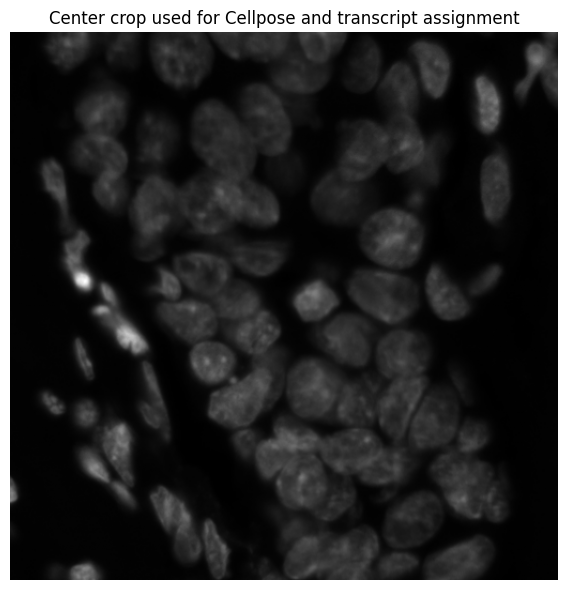

In [5]:
IMAGE_PATH = find_first_morphology_image(MORPHOLOGY_DIR)
print(f"Using image: {IMAGE_PATH}")
img_crop, start_x, start_y = load_center_crop(IMAGE_PATH, CROP_SIZE)
print("Image crop shape:", img_crop.shape)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_crop, cmap="gray")
ax.set_title("Center crop used for Cellpose and transcript assignment")
ax.axis("off")
plt.tight_layout()
savefig("evaluation_center_crop.png")
plt.show()

## 3 · Marker gene evaluation

In [6]:
available_markers = {}
for marker_group, genes in MARKER_GENES.items():
    present = [g for g in genes if g in cells_expr.columns]
    missing = [g for g in genes if g not in cells_expr.columns]
    if present:
        available_markers[marker_group] = present
    if missing:
        print(f"{marker_group}: markers not in panel/expression matrix: {missing}")

print("\nMarkers available for evaluation:")
for marker_group, genes in available_markers.items():
    print(f"  {marker_group}: {genes}")

if not available_markers:
    raise ValueError("No marker genes were found in the cell expression matrix.")

cells_with_pred = cells_expr.copy()
cells_with_pred["predicted_cell_type"] = predictions_raw["predicted_cell_type"]
rows = []
for marker_group, genes in available_markers.items():
    mean_expr = cells_with_pred.groupby("predicted_cell_type")[genes].mean().mean(axis=1)
    mean_expr.name = marker_group
    rows.append(mean_expr)

marker_df      = pd.DataFrame(rows).fillna(0)
marker_df_norm = marker_df.div(marker_df.max(axis=1) + 1e-9, axis=0)
print("\nMarker matrix shape:", marker_df.shape)
display(marker_df_norm)

fibroblast: markers not in panel/expression matrix: ['COL1A1', 'COL1A2']
myofibroblast: markers not in panel/expression matrix: ['ACTA2', 'TAGLN', 'COL3A1']
endothelial: markers not in panel/expression matrix: ['VWF', 'RAMP2']
vascular_smooth_muscle: markers not in panel/expression matrix: ['ACTA2', 'TAGLN']
immune: markers not in panel/expression matrix: ['PTPRC', 'LYZ']
epithelial: markers not in panel/expression matrix: ['KRT8', 'KRT18', 'KRT19']

Markers available for evaluation:
  fibroblast: ['DCN', 'LUM', 'PDGFRA']
  myofibroblast: ['MYL9']
  endothelial: ['PECAM1', 'KDR', 'ENG']
  pericyte: ['RGS5', 'PDGFRB', 'MCAM', 'CSPG4']
  vascular_smooth_muscle: ['MYH11', 'MYLK']
  cycling: ['MKI67', 'TOP2A', 'UBE2C', 'CENPF']
  immune: ['CD3D', 'CD3E', 'MS4A1']
  epithelial: ['EPCAM']

Marker matrix shape: (8, 8)


predicted_cell_type,endothelial cell,endothelial cell of artery,endothelial cell of vascular tree,fibroblast,myofibroblast cell,pericyte,vascular associated smooth muscle cell,vein endothelial cell
fibroblast,0.000000,0.00,0.0,1.000000,0.000000,0.000000,0.0,0.000000
myofibroblast,0.000000,0.00,0.0,0.347222,1.000000,0.000000,0.0,0.260417
endothelial,0.701754,0.00,0.0,0.701754,0.000000,0.000000,0.0,1.000000
pericyte,0.000000,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.000000
vascular_smooth_muscle,0.357143,1.00,0.0,0.000000,0.285714,0.446429,0.0,0.089286
cycling,0.533333,0.96,0.0,1.000000,0.000000,0.000000,0.0,0.000000
immune,0.829630,0.00,0.0,0.000000,0.000000,1.000000,0.0,0.222222
epithelial,0.000000,0.00,0.0,0.000000,0.000000,0.000000,0.0,0.000000


Saved → ../outputs/figures/marker_gene_heatmap_ordered.png


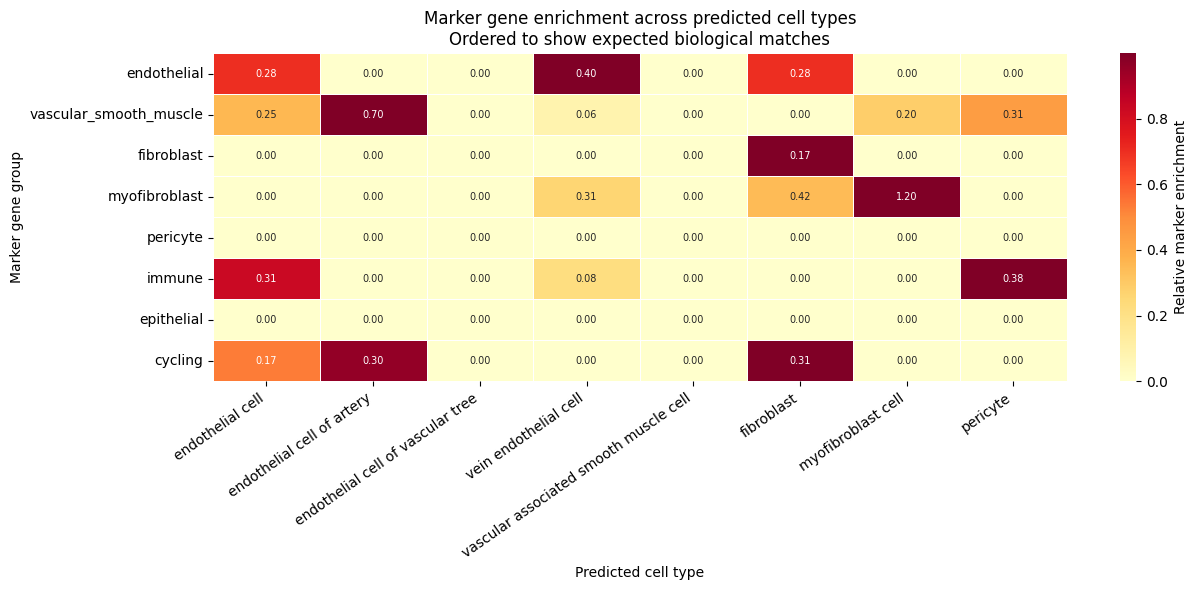

In [7]:
# Ordered marker heatmap — matched row/column ordering shows expected biological alignment.
marker_to_predicted_type = {
    "endothelial":            "endothelial cell",
    "vascular_smooth_muscle": "vascular associated smooth muscle cell",
    "fibroblast":             "fibroblast",
    "myofibroblast":          "myofibroblast cell",
    "pericyte":               "pericyte",
    "immune":                 None,
    "epithelial":             None,
    "cycling":                None,
}
ordered_marker_groups = [
    "endothelial", "vascular_smooth_muscle", "fibroblast",
    "myofibroblast", "pericyte", "immune", "epithelial", "cycling",
]
ordered_cell_types = [
    "endothelial cell", "endothelial cell of artery",
    "endothelial cell of vascular tree", "vein endothelial cell",
    "vascular associated smooth muscle cell", "fibroblast",
    "myofibroblast cell", "pericyte",
]

ordered_marker_groups = [m for m in ordered_marker_groups if m in marker_df_norm.index]
ordered_cell_types    = [c for c in ordered_cell_types    if c in marker_df_norm.columns]
marker_df_plot        = marker_df_norm.loc[ordered_marker_groups, ordered_cell_types]
marker_df_annot       = marker_df.loc[ordered_marker_groups, ordered_cell_types]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    marker_df_plot,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.4,
    annot=marker_df_annot.round(2),
    fmt=".2f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Relative marker enrichment"},
)
ax.set_title(
    "Marker gene enrichment across predicted cell types\n"
    "Ordered to show expected biological matches"
)
ax.set_xlabel("Predicted cell type")
ax.set_ylabel("Marker gene group")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
savefig("marker_gene_heatmap_ordered.png")
plt.show()

### Interpretation of marker gene enrichment heatmap

This heatmap evaluates whether the cell-type predictions are biologically consistent with
known marker gene groups.  In an ideal case we would see a strong diagonal — each marker
group most enriched in its corresponding predicted cell type.  The pattern here is only
partially diagonal, which reflects that predictions carry some biological signal but remain
noisy and ambiguous.

The strongest signal appears for **myofibroblast** (highly enriched in the predicted
myofibroblast category) and **fibroblast** (moderately enriched).  Endothelial markers
spread across several vascular subtypes, which is biologically plausible but indicates
difficulty separating endothelial subtypes.  Absent signals for **pericyte** and
**epithelial** likely reflect missing canonical markers from the Xenium panel rather than
incorrect assignments.

This partial consistency motivates the re-segmentation approach: the signal exists, but
the Cellpose boundaries may be misaligning transcripts for a subset of cells.


## 4 · Baseline + subset-driven confidence scoring

In [ ]:
# Full-gene confidence (calibrated)
# Data-driven thresholds: 25th-percentile of each score distribution.
# This avoids hard-coding arbitrary cutoffs.
similarity_threshold = predictions_raw["best_similarity"].quantile(0.25)
margin_threshold     = predictions_raw["margin"].quantile(0.25) if "margin" in predictions_raw.columns else DEFAULT_MARGIN_THRESHOLD

# Compute margin if not already present.
if "margin" not in predictions_raw.columns:
    sorted_scores = np.sort(sim_df.values, axis=1)
    predictions_raw["margin"] = sorted_scores[:, -1] - sorted_scores[:, -2]
    margin_threshold = predictions_raw["margin"].quantile(0.25)

# Calibrated predictions used for ablation.
predictions = add_confidence_flags(
    predictions_raw,
    sim_df,
    similarity_threshold,
    margin_threshold,
)

print("Full-gene calibrated confidence thresholds:")
print(f"  similarity threshold (25th pct) = {similarity_threshold:.4f}")
print(f"  margin threshold     (25th pct) = {margin_threshold:.6f}")
print(f"  low-confidence cells (full-gene) = {predictions['low_confidence'].sum()} / {len(predictions)}")

# Integrate subset-driven confidence from NB04
# Cells that showed no signal in the focused gene subset are flagged separately.
# This is distinct from low cosine similarity: it means the cell's transcript
# capture in that region was insufficient even for the most discriminative genes —
# a direct pointer to segmentation problems rather than typing uncertainty.
predictions = flag_subset_driven(predictions, subset_predictions)

n_combined = predictions["low_confidence_combined"].sum()
n_subset_only = (predictions["subset_no_signal"] & ~predictions["low_confidence"]).sum()

print("\nSubset-driven confidence integration:")
print(f"  cells with no subset signal:                 {predictions['subset_no_signal'].sum()} / {len(predictions)}")
print(f"  cells flagged by full-gene criterion alone:  {predictions['low_confidence'].sum()} / {len(predictions)}")
print(f"  cells flagged by subset signal only:         {n_subset_only} / {len(predictions)}")
print(f"  cells flagged by combined criterion:         {n_combined} / {len(predictions)}")

display(predictions.head())

Full-gene calibrated confidence thresholds:
  similarity threshold (25th pct) = 0.0769
  margin threshold     (25th pct) = 0.000931
  low-confidence cells (full-gene) = 38 / 82

Subset-driven confidence integration:
  cells with no subset signal:                 51 / 82
  cells flagged by full-gene criterion alone:  38 / 82
  cells flagged by subset signal only:         26 / 82
  cells flagged by combined criterion:         64 / 82


,predicted_cell_type,best_similarity,margin,confidence,low_similarity,low_margin,low_confidence,subset_no_signal,subset_score,subset_margin,low_confidence_combined
cell_1,endothelial cell of artery,0.123726,0.000517,0.123726,False,True,True,False,0.320470,0.085091,True
cell_2,fibroblast,0.089567,0.003142,0.089567,False,False,False,True,NaN,NaN,True
cell_3,endothelial cell,0.154247,0.011477,0.154247,False,False,False,False,0.228024,0.011555,False
cell_4,fibroblast,0.100240,0.002013,0.100240,False,False,False,False,0.712615,0.075483,False
cell_5,endothelial cell,0.098915,0.001955,0.098915,False,False,False,False,0.019024,0.008587,False


Saved → ../outputs/figures/gene_subset_vs_fullgene_confidence.png


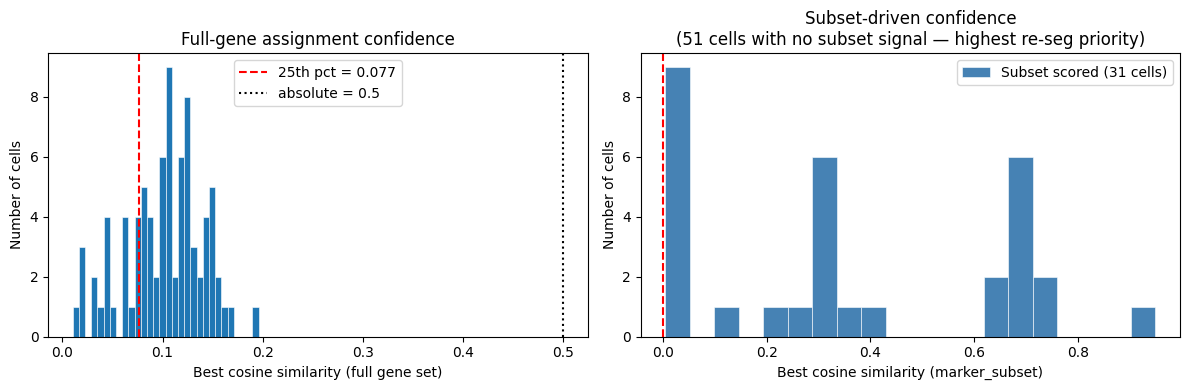

In [ ]:
# Visualise full-gene vs. subset confidence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(predictions["confidence"], bins=30, edgecolor="white", linewidth=0.4)
axes[0].axvline(similarity_threshold, color="red",   linestyle="--",
                label=f"25th pct = {similarity_threshold:.3f}")
axes[0].axvline(DEFAULT_CONFIDENCE_THRESHOLD, color="black", linestyle=":",
                label=f"absolute = {DEFAULT_CONFIDENCE_THRESHOLD}")
axes[0].set_xlabel("Best cosine similarity (full gene set)")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Full-gene assignment confidence")
axes[0].legend()

axes[1].hist(
    predictions["subset_score"].dropna(),
    bins=20,
    edgecolor="white",
    linewidth=0.4,
    label=f"Subset scored ({(~predictions['subset_no_signal']).sum()} cells)",
    color="steelblue",
)
n_no_signal = predictions["subset_no_signal"].sum()
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel(f"Best cosine similarity ({SUBSET_TAG})")
axes[1].set_ylabel("Number of cells")
axes[1].set_title(
    f"Subset-driven confidence\n"
    f"({n_no_signal} cells with no subset signal — highest re-seg priority)"
)
axes[1].legend()

plt.tight_layout()
savefig("gene_subset_vs_fullgene_confidence.png")
plt.show()

## 5 · Biological correction function

In [ ]:
def _rejection_row(config, cell_id_str, before_score, before_type, decision, extra=None):
    row = {
        "experiment":             config.name,
        "cell_id":                cell_id_str,
        "before_score":           before_score,
        "candidate_after_score":  before_score,
        "after_score":            before_score,
        "before_type":            before_type,
        "candidate_after_type":   before_type,
        "after_type":             before_type,
        "accepted":               False,
        "decision":               decision,
        "improvement":            0.0,
        "raw_candidate_improvement": 0.0,
        "patch_size":             config.patch_size,
        "retry_diameter":         config.retry_diameter,
    }
    if extra:
        row.update(extra)
    return row


def run_biological_correction_experiment(
    config, predictions_input, sim_matrix, masks, img_crop, assigned_tx, prototypes
):
    """
    For each low-confidence cell, extract a small image patch around the cell centre,
    re-run Cellpose with a potentially different diameter, re-assign transcripts in
    the patch, and compute cosine similarity for the new segmentation.

    The new segmentation is accepted only when its cosine similarity exceeds the
    original score by at least config.accept_tolerance.  This ensures we never
    silently degrade assignments — every accepted correction is verifiably better.

    When config.use_subset_criterion is True, cells flagged by the combined
    full-gene + subset criterion are selected.  This gives higher recall for
    poorly segmented cells at the cost of considering more candidates.
    """
    predictions_flagged = add_confidence_flags(
        pred_df=predictions_input,
        sim_matrix=sim_matrix,
        confidence_threshold=config.confidence_threshold,
        margin_threshold=config.margin_threshold,
    )

    # Candidate selection
    if config.worst_quantile is not None:
        # Worst-N-percent mode: only re-segment the cells with the lowest scores.
        cutoff   = predictions_flagged["best_similarity"].quantile(config.worst_quantile)
        selected = predictions_flagged[predictions_flagged["best_similarity"] <= cutoff].copy()
    elif config.use_subset_criterion and "low_confidence_combined" in predictions_input.columns:
        # Subset-driven mode: include cells flagged by the gene-subset criterion
        # (no discriminative marker signal), even if their full-gene score is adequate.
        # These cells are the most likely to have been poorly segmented.
        selected = predictions_flagged[
            predictions_input["low_confidence_combined"].reindex(predictions_flagged.index, fill_value=False)
        ].copy()
    else:
        selected = predictions_flagged[predictions_flagged["low_confidence"]].copy()

    print(f"\nRunning experiment: {config.name}")
    print(f"  Selected cells:      {len(selected)} / {len(predictions_flagged)}")
    print(f"  Patch size:          {config.patch_size}")
    print(f"  Retry diameter:      {config.retry_diameter}")
    print(f"  Accept tolerance:    {config.accept_tolerance}")
    print(f"  Subset criterion:    {config.use_subset_criterion}")

    refined_predictions = predictions_flagged.copy()
    ablation_rows       = []
    proto_values        = prototypes.values
    shared_genes        = list(prototypes.columns)

    if not config.run_resegmentation or not CELLPOSE_AVAILABLE:
        print("  Re-segmentation unavailable / skipped. Creating no-correction table.")
        for cell_id_str, row in selected.iterrows():
            ablation_rows.append(
                _rejection_row(config, cell_id_str, row["best_similarity"],
                               row["predicted_cell_type"], "not_run")
            )
        return refined_predictions, pd.DataFrame(ablation_rows)

    model = models.CellposeModel(gpu=True)

    for cell_id_str, row in selected.iterrows():
        cell_id = parse_cell_id(cell_id_str)
        if cell_id is None:
            continue

        before_score = row["best_similarity"]
        before_type  = row["predicted_cell_type"]
        ys, xs       = np.where(masks == cell_id)

        if len(ys) == 0:
            ablation_rows.append(
                _rejection_row(config, cell_id_str, before_score, before_type,
                               "rejected_no_mask_pixels")
            )
            continue

        cy, cx = int(ys.mean()), int(xs.mean())
        y0 = max(0, cy - config.patch_size // 2)
        y1 = min(CROP_SIZE, cy + config.patch_size // 2)
        x0 = max(0, cx - config.patch_size // 2)
        x1 = min(CROP_SIZE, cx + config.patch_size // 2)
        patch = img_crop[y0:y1, x0:x1]

        if patch.size == 0:
            ablation_rows.append(
                _rejection_row(config, cell_id_str, before_score, before_type,
                               "rejected_empty_patch")
            )
            continue

        patch_masks, _, _ = model.eval(patch, diameter=config.retry_diameter, batch_size=1)
        patch_cy = (y1 - y0) // 2
        patch_cx = (x1 - x0) // 2
        new_cell_id = patch_masks[patch_cy, patch_cx]

        if new_cell_id == 0:
            ablation_rows.append(
                _rejection_row(config, cell_id_str, before_score, before_type,
                               "rejected_no_center_cell",
                               {"x0": x0, "x1": x1, "y0": y0, "y1": y1})
            )
            continue

        patch_tx = assigned_tx[
            (assigned_tx["x_local"] >= x0) & (assigned_tx["x_local"] < x1) &
            (assigned_tx["y_local"] >= y0) & (assigned_tx["y_local"] < y1)
        ].copy()

        if len(patch_tx) == 0:
            ablation_rows.append(
                _rejection_row(config, cell_id_str, before_score, before_type,
                               "rejected_no_transcripts",
                               {"x0": x0, "x1": x1, "y0": y0, "y1": y1})
            )
            continue

        patch_tx["patch_cell"] = patch_masks[
            (patch_tx["y_local"] - y0).astype(int).clip(0, patch_masks.shape[0] - 1),
            (patch_tx["x_local"] - x0).astype(int).clip(0, patch_masks.shape[1] - 1),
        ]
        new_cell_tx = patch_tx[patch_tx["patch_cell"] == new_cell_id]

        if len(new_cell_tx) == 0:
            ablation_rows.append(
                _rejection_row(config, cell_id_str, before_score, before_type,
                               "rejected_no_transcripts_in_new_cell",
                               {"x0": x0, "x1": x1, "y0": y0, "y1": y1})
            )
            continue

        new_expr = (
            new_cell_tx["feature_name"]
            .value_counts()
            .reindex(shared_genes, fill_value=0)
            .values
            .reshape(1, -1)
        )
        if new_expr.sum() == 0:
            ablation_rows.append(
                _rejection_row(config, cell_id_str, before_score, before_type,
                               "rejected_zero_expression",
                               {"x0": x0, "x1": x1, "y0": y0, "y1": y1})
            )
            continue

        new_expr_norm          = normalize(new_expr, norm="l2")
        scores                 = cos_sim(new_expr_norm, proto_values)[0]
        candidate_after_score  = float(scores.max())
        candidate_after_type   = prototypes.index[scores.argmax()]
        candidate_margin       = float(np.sort(scores)[-1] - np.sort(scores)[-2])
        raw_improvement        = candidate_after_score - before_score
        accepted               = candidate_after_score >= before_score + config.accept_tolerance

        if accepted:
            refined_predictions.loc[cell_id_str, "predicted_cell_type"] = candidate_after_type
            refined_predictions.loc[cell_id_str, "best_similarity"]     = candidate_after_score
            refined_predictions.loc[cell_id_str, "confidence"]          = candidate_after_score
            refined_predictions.loc[cell_id_str, "margin"]              = candidate_margin
            refined_predictions.loc[cell_id_str, "low_similarity"]      = candidate_after_score < config.confidence_threshold
            refined_predictions.loc[cell_id_str, "low_margin"]          = candidate_margin < config.margin_threshold
            refined_predictions.loc[cell_id_str, "low_confidence"]      = (
                refined_predictions.loc[cell_id_str, "low_similarity"] or
                refined_predictions.loc[cell_id_str, "low_margin"]
            )

        ablation_rows.append({
            "experiment":                config.name,
            "cell_id":                   cell_id_str,
            "before_score":              before_score,
            "candidate_after_score":     candidate_after_score,
            "after_score":               candidate_after_score if accepted else before_score,
            "before_type":               before_type,
            "candidate_after_type":      candidate_after_type,
            "after_type":                candidate_after_type if accepted else before_type,
            "accepted":                  accepted,
            "decision":                  "accepted_improved" if accepted else "rejected_no_improvement",
            "improvement":               raw_improvement if accepted else 0.0,
            "raw_candidate_improvement": raw_improvement,
            "patch_size":                config.patch_size,
            "retry_diameter":            config.retry_diameter,
            "x0": x0, "x1": x1, "y0": y0, "y1": y1,
        })

    return refined_predictions, pd.DataFrame(ablation_rows)

## 6 · Define ablation experiments

In [ ]:
# Ablation configurations
# Five experiments test how different re-segmentation settings affect the
# number and quality of accepted corrections.
#
# NEW: Two experiments (marked use_subset_criterion=True) use the combined
# confidence criterion from NB04.  These treat cells with no gene-subset signal
# as high-priority candidates for re-segmentation, directly linking the
# gene-subset analysis to the correction loop.

experiment_configs = [
    # Baseline: no correction at all
    AblationConfig(
        "baseline_no_correction",
        confidence_threshold=similarity_threshold,
        margin_threshold=margin_threshold,
        patch_size=80,
        retry_diameter=20,
        accept_tolerance=0.0,
        run_resegmentation=False,
        use_subset_criterion=False,
    ),

    # Full-gene criterion, strict acceptance
    AblationConfig(
        "strict_patch80_diam20",
        confidence_threshold=similarity_threshold,
        margin_threshold=margin_threshold,
        patch_size=80,
        retry_diameter=20,
        accept_tolerance=1e-4,
        use_subset_criterion=False,
    ),

    # Full-gene criterion, relaxed acceptance
    AblationConfig(
        "relaxed_patch80_diam20",
        confidence_threshold=similarity_threshold,
        margin_threshold=margin_threshold,
        patch_size=80,
        retry_diameter=20,
        accept_tolerance=0.0,
        use_subset_criterion=False,
    ),

    # Full-gene criterion, larger patch
    AblationConfig(
        "larger_patch150_diam20",
        confidence_threshold=similarity_threshold,
        margin_threshold=margin_threshold,
        patch_size=150,
        retry_diameter=20,
        accept_tolerance=0.0,
        use_subset_criterion=False,
    ),

    # Worst-25% cells only (full-gene)
    AblationConfig(
        "worst25_patch150_diam20",
        confidence_threshold=similarity_threshold,
        margin_threshold=margin_threshold,
        patch_size=150,
        retry_diameter=20,
        accept_tolerance=0.0,
        worst_quantile=0.25,
        use_subset_criterion=False,
    ),

    # Subset-driven criterion, patch 80
    # Selects cells flagged by either the full-gene low-confidence test OR the
    # gene-subset no-signal test.  The larger candidate set targets cells most
    # likely to have been mis-segmented (insufficient discriminative transcripts).
    AblationConfig(
        "subset_driven_patch80_diam20",
        confidence_threshold=similarity_threshold,
        margin_threshold=margin_threshold,
        patch_size=80,
        retry_diameter=20,
        accept_tolerance=0.0,
        use_subset_criterion=True,
    ),

    # Subset-driven criterion, larger patch 
    AblationConfig(
        "subset_driven_patch150_diam20",
        confidence_threshold=similarity_threshold,
        margin_threshold=margin_threshold,
        patch_size=150,
        retry_diameter=20,
        accept_tolerance=0.0,
        use_subset_criterion=True,
    ),
]

experiment_config_df = pd.DataFrame([cfg.__dict__ for cfg in experiment_configs])
display(experiment_config_df)

,name,confidence_threshold,margin_threshold,patch_size,retry_diameter,accept_tolerance,worst_quantile,run_resegmentation,use_subset_criterion
0,baseline_no_correction,0.076905,0.000931,80,20,0.0000,NaN,False,False
1,strict_patch80_diam20,0.076905,0.000931,80,20,0.0001,NaN,True,False
2,relaxed_patch80_diam20,0.076905,0.000931,80,20,0.0000,NaN,True,False
3,larger_patch150_diam20,0.076905,0.000931,150,20,0.0000,NaN,True,False
4,worst25_patch150_diam20,0.076905,0.000931,150,20,0.0000,0.25,True,False
5,subset_driven_patch80_diam20,0.076905,0.000931,80,20,0.0000,NaN,True,True
6,subset_driven_patch150_diam20,0.076905,0.000931,150,20,0.0000,NaN,True,True


## 7 · Run ablation experiments

In [12]:
all_ablation_results = []
refined_by_experiment = {}

for cfg in experiment_configs:
    # Pass the full predictions dataframe (which now includes subset_no_signal
    # and low_confidence_combined columns) so the correction function can use
    # the subset-driven criterion when requested.
    refined_pred, ablation_df = run_biological_correction_experiment(
        config=cfg,
        predictions_input=predictions,
        sim_matrix=sim_df,
        masks=masks,
        img_crop=img_crop,
        assigned_tx=assigned_tx,
        prototypes=prototypes,
    )

    refined_by_experiment[cfg.name] = refined_pred

    if len(ablation_df) > 0:
        all_ablation_results.append(ablation_df)

if not all_ablation_results:
    raise ValueError("No ablation results were produced.")

all_results_df = pd.concat(all_ablation_results, ignore_index=True)
all_results_df.to_csv(ALL_RESULTS_PATH, index=False)

print(f"Saved all ablation cell-level results → {ALL_RESULTS_PATH}")

print("\nDecision counts by experiment:")
decision_counts = pd.crosstab(all_results_df["experiment"], all_results_df["decision"])
display(decision_counts)
decision_counts.to_csv(OUTPUT_DIR / "ablation_decision_counts.csv")


Running experiment: baseline_no_correction
  Selected cells:      38 / 82
  Patch size:          80
  Retry diameter:      20
  Accept tolerance:    0.0
  Subset criterion:    False
  Re-segmentation unavailable / skipped. Creating no-correction table.

Running experiment: strict_patch80_diam20
  Selected cells:      38 / 82
  Patch size:          80
  Retry diameter:      20
  Accept tolerance:    0.0001
  Subset criterion:    False


/Users/mahsa/Projects/Computational-Genomics-Project/.venv/lib/python3.10/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),



Running experiment: relaxed_patch80_diam20
  Selected cells:      38 / 82
  Patch size:          80
  Retry diameter:      20
  Accept tolerance:    0.0
  Subset criterion:    False

Running experiment: larger_patch150_diam20
  Selected cells:      38 / 82
  Patch size:          150
  Retry diameter:      20
  Accept tolerance:    0.0
  Subset criterion:    False

Running experiment: worst25_patch150_diam20
  Selected cells:      21 / 82
  Patch size:          150
  Retry diameter:      20
  Accept tolerance:    0.0
  Subset criterion:    False

Running experiment: subset_driven_patch80_diam20
  Selected cells:      64 / 82
  Patch size:          80
  Retry diameter:      20
  Accept tolerance:    0.0
  Subset criterion:    True

Running experiment: subset_driven_patch150_diam20
  Selected cells:      64 / 82
  Patch size:          150
  Retry diameter:      20
  Accept tolerance:    0.0
  Subset criterion:    True
Saved all ablation cell-level results → ../outputs/ablation_all_cell_r

decision,accepted_improved,not_run,rejected_no_center_cell,rejected_no_improvement
experiment,,,,
baseline_no_correction,0,38,0,0
larger_patch150_diam20,14,0,10,14
relaxed_patch80_diam20,11,0,6,21
strict_patch80_diam20,10,0,6,22
subset_driven_patch150_diam20,23,0,16,25
subset_driven_patch80_diam20,14,0,9,41
worst25_patch150_diam20,9,0,7,5


## 8 · Summarise ablation metrics

In [13]:
def summarize_experiment(name, refined_pred, ablation_df):
    before_scores = predictions_raw["best_similarity"]
    after_scores  = refined_pred["best_similarity"]

    before_flagged = add_confidence_flags(
        predictions_raw, sim_df, similarity_threshold, margin_threshold
    )
    refined_scored = add_confidence_flags(
        refined_pred,    sim_df, similarity_threshold, margin_threshold
    )

    diff         = after_scores - before_scores
    n_total      = len(predictions_raw)
    n_considered = len(ablation_df)
    n_accepted   = int(ablation_df["accepted"].sum()) if len(ablation_df) else 0
    n_rejected   = n_considered - n_accepted

    improved_scores = (
        ablation_df.loc[ablation_df["accepted"], "improvement"]
        if len(ablation_df) else pd.Series(dtype=float)
    )

    return {
        "experiment":                    name,
        "total_segmented_cells":         n_total,
        "mean_cosine_before":            before_scores.mean(),
        "mean_cosine_after":             after_scores.mean(),
        "median_cosine_before":          before_scores.median(),
        "median_cosine_after":           after_scores.median(),
        "std_cosine_before":             before_scores.std(),
        "std_cosine_after":              after_scores.std(),
        "low_confidence_before":         int(before_flagged["low_confidence"].sum()),
        "low_confidence_after":          int(refined_scored["low_confidence"].sum()),
        "percent_low_confidence_before": 100 * before_flagged["low_confidence"].sum() / n_total,
        "percent_low_confidence_after":  100 * refined_scored["low_confidence"].sum() / n_total,
        "cells_considered_for_correction": n_considered,
        "cells_improved":                n_accepted,
        "percent_improved_of_considered": 100 * n_accepted / max(n_considered, 1),
        "cells_rejected_or_unchanged":   n_rejected,
        "average_cosine_improvement_among_improved": improved_scores.mean() if len(improved_scores) else 0,
        "max_cosine_improvement":        improved_scores.max() if len(improved_scores) else 0,
        "overall_mean_delta":            diff.mean(),
        "overall_max_delta":             diff.max(),
        "cells_with_any_score_change":   int((diff != 0).sum()),
    }


metrics_rows = []
for cfg in experiment_configs:
    refined_pred = refined_by_experiment[cfg.name]
    ablation_df  = all_results_df[all_results_df["experiment"] == cfg.name].copy()
    metrics_rows.append(summarize_experiment(cfg.name, refined_pred, ablation_df))

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(EXPERIMENT_METRICS_PATH, index=False)

print(f"Saved experiment metrics → {EXPERIMENT_METRICS_PATH}")
display(metrics_df)

Saved experiment metrics → ../outputs/ablation_experiment_metrics.csv


,experiment,total_segmented_cells,mean_cosine_before,mean_cosine_after,median_cosine_before,median_cosine_after,std_cosine_before,std_cosine_after,low_confidence_before,low_confidence_after,...,percent_low_confidence_after,cells_considered_for_correction,cells_improved,percent_improved_of_considered,cells_rejected_or_unchanged,average_cosine_improvement_among_improved,max_cosine_improvement,overall_mean_delta,overall_max_delta,cells_with_any_score_change
0,baseline_no_correction,82,0.100875,0.100875,0.103892,0.103892,0.039028,0.039028,38,38,...,46.341463,38,0,0.000000,38,0.000000,0.000000,0.000000,0.000000,0
1,strict_patch80_diam20,82,0.100875,0.101201,0.103892,0.103892,0.039028,0.038740,38,38,...,46.341463,38,10,26.315789,28,0.002677,0.009165,0.000326,0.009165,10
2,relaxed_patch80_diam20,82,0.100875,0.101201,0.103892,0.103892,0.039028,0.038740,38,38,...,46.341463,38,11,28.947368,27,0.002434,0.009165,0.000326,0.009165,11
3,larger_patch150_diam20,82,0.100875,0.101016,0.103892,0.103892,0.039028,0.039070,38,38,...,46.341463,38,14,36.842105,24,0.000825,0.003107,0.000141,0.003107,14
4,worst25_patch150_diam20,82,0.100875,0.100922,0.103892,0.103892,0.039028,0.038973,38,38,...,46.341463,21,9,42.857143,12,0.000432,0.001133,0.000047,0.001133,9
5,subset_driven_patch80_diam20,82,0.100875,0.101215,0.103892,0.103892,0.039028,0.038746,38,38,...,46.341463,64,14,21.875000,50,0.001990,0.009165,0.000340,0.009165,14
6,subset_driven_patch150_diam20,82,0.100875,0.101721,0.103892,0.104936,0.039028,0.039332,38,38,...,46.341463,64,23,35.937500,41,0.003015,0.053997,0.000846,0.053997,23


In [14]:
# Select the best experiment: prioritise percent-improved, then average improvement,
# then raw cell count.  Baseline is excluded because it has zero corrections by design.
best_row = (
    metrics_df[metrics_df["experiment"] != "baseline_no_correction"]
    .sort_values(
        ["percent_improved_of_considered",
         "average_cosine_improvement_among_improved",
         "cells_improved"],
        ascending=False,
    )
    .iloc[0]
)

BEST_EXPERIMENT          = best_row["experiment"]
best_refined_predictions = refined_by_experiment[BEST_EXPERIMENT].copy()
best_ablation_df         = all_results_df[all_results_df["experiment"] == BEST_EXPERIMENT].copy()

best_refined_predictions.to_csv(BEST_REFINED_PATH)

print("Best experiment:", BEST_EXPERIMENT)
display(best_row.to_frame(name="value"))
print(f"Saved best refined predictions → {BEST_REFINED_PATH}")

Best experiment: worst25_patch150_diam20


,value
experiment,worst25_patch150_diam20
total_segmented_cells,82
mean_cosine_before,0.100875
mean_cosine_after,0.100922
median_cosine_before,0.103892
median_cosine_after,0.103892
std_cosine_before,0.039028
std_cosine_after,0.038973
low_confidence_before,38
low_confidence_after,38


Saved best refined predictions → ../outputs/cell_type_predictions_refined_best.csv


## 9 · Visualise ablation experiment results

Saved → ../outputs/figures/ablation_experiment_summary.png


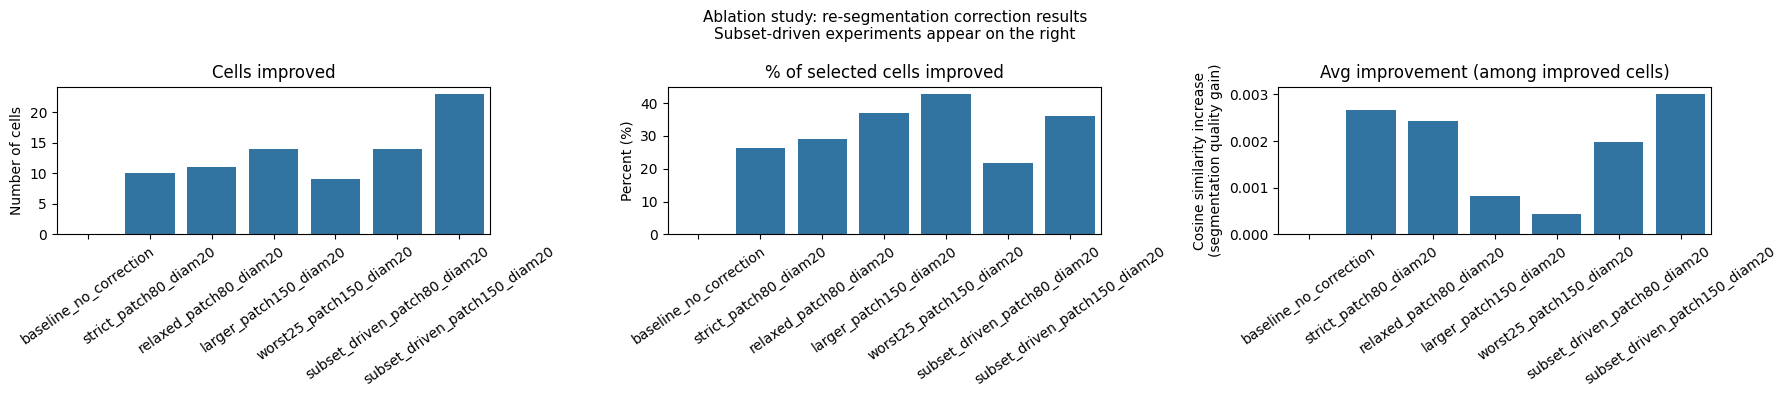

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(data=metrics_df, x="experiment", y="cells_improved", ax=axes[0])
axes[0].set_title("Cells improved")
axes[0].set_ylabel("Number of cells")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=metrics_df, x="experiment", y="percent_improved_of_considered", ax=axes[1])
axes[1].set_title("% of selected cells improved")
axes[1].set_ylabel("Percent (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=35)

sns.barplot(
    data=metrics_df,
    x="experiment",
    y="average_cosine_improvement_among_improved",
    ax=axes[2],
)
axes[2].set_title("Avg improvement (among improved cells)")
axes[2].set_ylabel("Cosine similarity increase\n(segmentation quality gain)")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=35)

plt.suptitle(
    "Ablation study: re-segmentation correction results\n"
    "Subset-driven experiments appear on the right",
    fontsize=11,
)
plt.tight_layout()
savefig("ablation_experiment_summary.png")
plt.show()

## 10 · Before/after plots for best experiment

Saved → ../outputs/figures/cosine_before_after_best_histogram.png


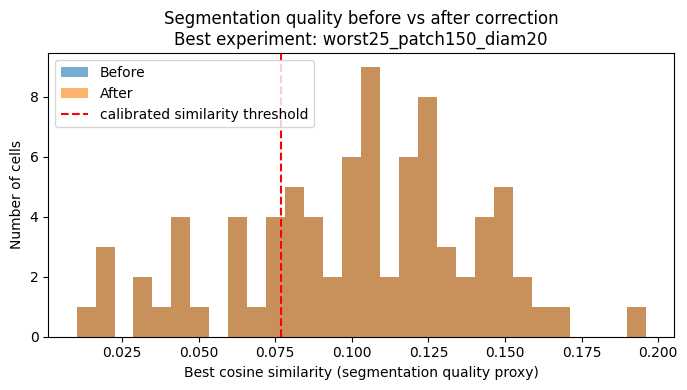

Saved → ../outputs/figures/cosine_improvement_distribution_best.png


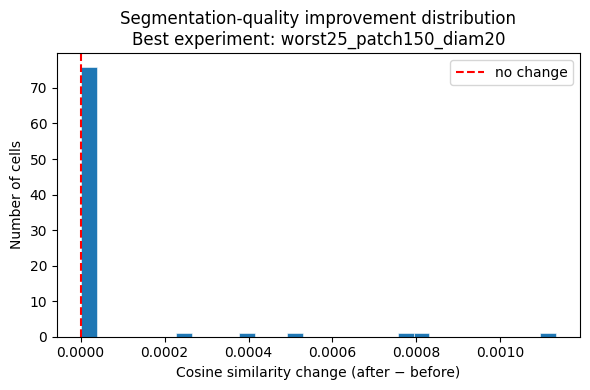

count    82.000000
mean      0.000047
std       0.000188
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       0.001133
Name: delta, dtype: float64
Cells improved: 9
Cells unchanged: 73
Max improvement: 0.0011334482335396828


In [16]:
comparison_df = pd.DataFrame({
    "before": predictions_raw["best_similarity"],
    "after":  best_refined_predictions["best_similarity"],
})
comparison_df["delta"] = comparison_df["after"] - comparison_df["before"]

comparison_long = comparison_df.reset_index().melt(
    id_vars="index",
    value_vars=["before", "after"],
    var_name="condition",
    value_name="cosine_similarity",
)

# Histogram overlay.
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(comparison_df["before"], bins=30, alpha=0.6, label="Before")
ax.hist(comparison_df["after"],  bins=30, alpha=0.6, label="After")
ax.axvline(similarity_threshold, color="red", linestyle="--",
           label="calibrated similarity threshold")
ax.set_xlabel("Best cosine similarity (segmentation quality proxy)")
ax.set_ylabel("Number of cells")
ax.set_title(f"Segmentation quality before vs after correction\nBest experiment: {BEST_EXPERIMENT}")
ax.legend()
plt.tight_layout()
savefig("cosine_before_after_best_histogram.png")
plt.show()

# Delta distribution.
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(comparison_df["delta"], bins=30, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="red", linestyle="--", label="no change")
ax.set_xlabel("Cosine similarity change (after − before)")
ax.set_ylabel("Number of cells")
ax.set_title(f"Segmentation-quality improvement distribution\nBest experiment: {BEST_EXPERIMENT}")
ax.legend()
plt.tight_layout()
savefig("cosine_improvement_distribution_best.png")
plt.show()

print(comparison_df["delta"].describe())
print("Cells improved:", (comparison_df["delta"] > 0).sum())
print("Cells unchanged:", (comparison_df["delta"] == 0).sum())
print("Max improvement:", comparison_df["delta"].max())

## 11 · Spatial confidence map

Saved → ../outputs/figures/confidence_map.png


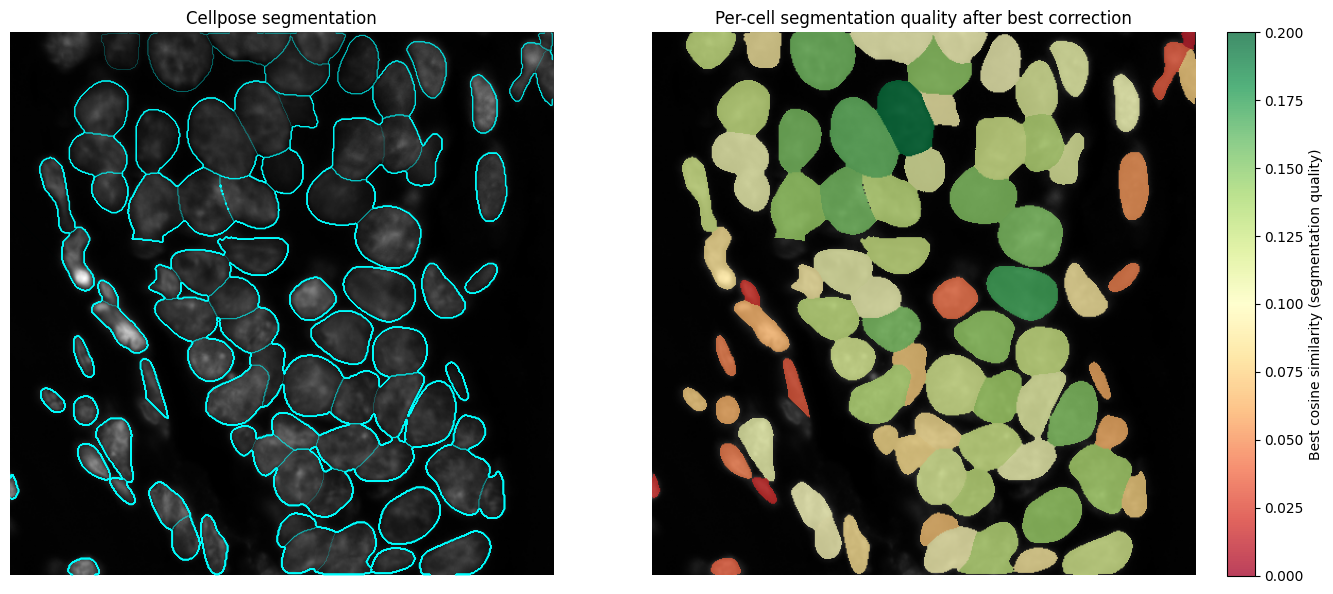

In [17]:
best_predictions_with_flags = add_confidence_flags(
    best_refined_predictions, sim_df,
    DEFAULT_CONFIDENCE_THRESHOLD, DEFAULT_MARGIN_THRESHOLD
)

confidence_map = np.zeros(masks.shape, dtype=float)
for cell_id_str, row in best_predictions_with_flags.iterrows():
    cell_id = parse_cell_id(cell_id_str)
    if cell_id is None:
        continue
    confidence_map[masks == cell_id] = row["confidence"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_crop, cmap="gray")
levels = np.unique(masks)
levels = levels[levels > 0]
if len(levels):
    axes[0].contour(masks, levels=levels, linewidths=0.3, colors="cyan", alpha=0.5)
axes[0].set_title("Cellpose segmentation")
axes[0].axis("off")

axes[1].imshow(img_crop, cmap="gray")
conf_masked = np.ma.masked_where(masks == 0, confidence_map)
im = axes[1].imshow(
    conf_masked, cmap="RdYlGn",
    vmin=0, vmax=max(0.2, confidence_map.max()), alpha=0.75
)
plt.colorbar(im, ax=axes[1], fraction=0.046,
             label="Best cosine similarity (segmentation quality)")
axes[1].set_title("Per-cell segmentation quality after best correction")
axes[1].axis("off")

plt.tight_layout()
savefig("confidence_map.png")
plt.show()

## 12 · Flagged cells overlay

Saved → ../outputs/figures/flagged_cells_overlay.png


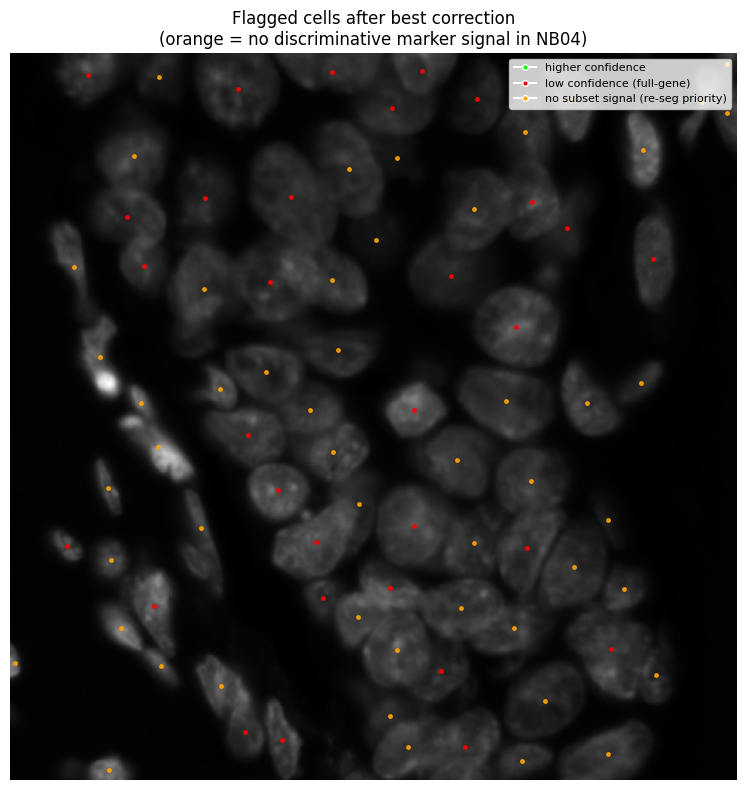

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img_crop, cmap="gray")

for cell_id_str, row in best_predictions_with_flags.iterrows():
    cell_id = parse_cell_id(cell_id_str)
    if cell_id is None:
        continue
    ys, xs = np.where(masks == cell_id)
    if len(ys) == 0:
        continue
    # Cells with no subset signal are shown in orange — these are the
    # highest-priority re-segmentation targets identified by the NB04 analysis.
    if predictions.loc[cell_id_str, "subset_no_signal"]:
        color = "orange"
    elif row["low_confidence"]:
        color = "red"
    else:
        color = "lime"
    ax.plot(xs.mean(), ys.mean(), ".", color=color, markersize=5, alpha=0.85)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], marker=".", color="w", markerfacecolor="lime",   markersize=8, label="higher confidence"),
    Line2D([0],[0], marker=".", color="w", markerfacecolor="red",    markersize=8, label="low confidence (full-gene)"),
    Line2D([0],[0], marker=".", color="w", markerfacecolor="orange", markersize=8, label="no subset signal (re-seg priority)"),
], loc="upper right", fontsize=8)
ax.set_title("Flagged cells after best correction\n(orange = no discriminative marker signal in NB04)")
ax.axis("off")
plt.tight_layout()
savefig("flagged_cells_overlay.png")
plt.show()

## 13 · Example corrected cells

Saved → ../outputs/figures/example_corrected_cell_01_cell_49.png


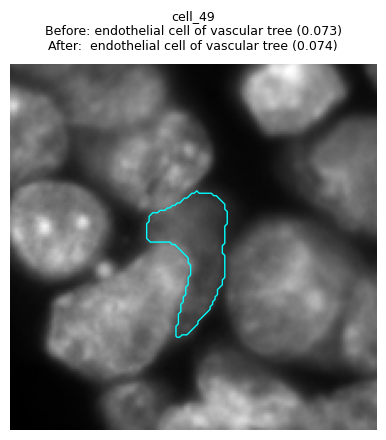

Saved → ../outputs/figures/example_corrected_cell_02_cell_51.png


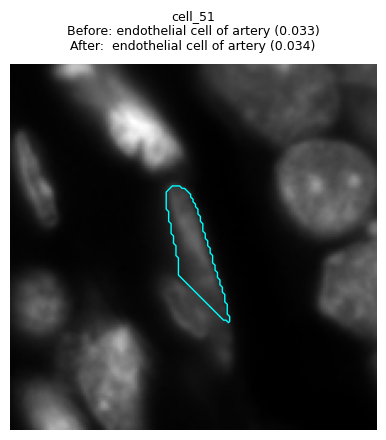

Saved → ../outputs/figures/example_corrected_cell_03_cell_47.png


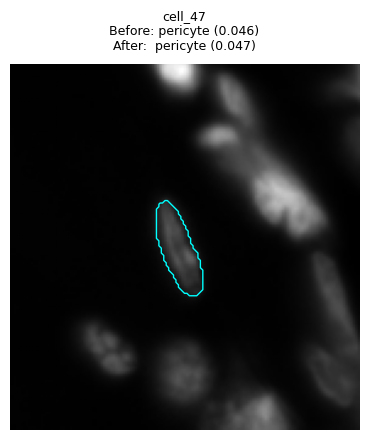

Saved → ../outputs/figures/example_corrected_cell_04_cell_70.png


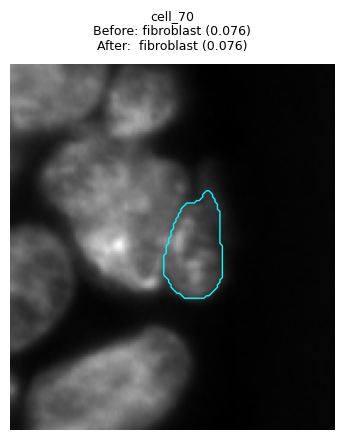

Saved → ../outputs/figures/example_corrected_cell_05_cell_66.png


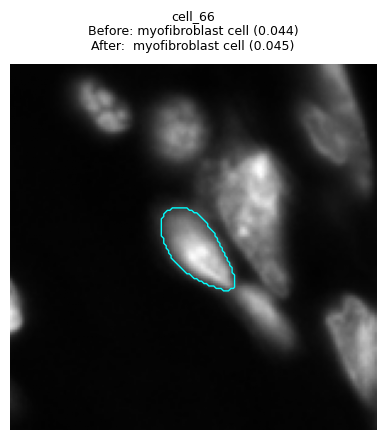

Saved → ../outputs/figures/example_corrected_cell_06_cell_60.png


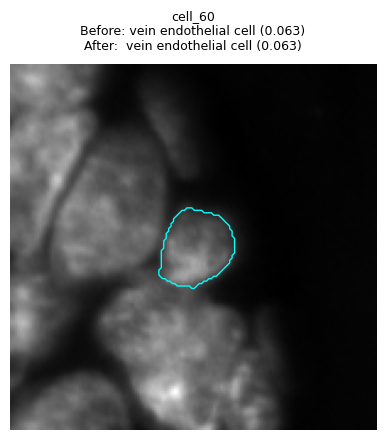

,experiment,cell_id,before_score,candidate_after_score,after_score,before_type,candidate_after_type,after_type,accepted,decision,improvement,raw_candidate_improvement,patch_size,retry_diameter,x0,x1,y0,y1
161,worst25_patch150_diam20,cell_49,0.072962,0.074096,0.074096,endothelial cell of vascular tree,endothelial cell of vascular tree,endothelial cell of vascular tree,True,accepted_improved,0.001133,0.001133,150,20,170.0,320.0,241.0,391.0
162,worst25_patch150_diam20,cell_51,0.032703,0.033529,0.033529,endothelial cell of artery,endothelial cell of artery,endothelial cell of artery,True,accepted_improved,0.000826,0.000826,150,20,59.0,209.0,258.0,408.0
160,worst25_patch150_diam20,cell_47,0.045817,0.046586,0.046586,pericyte,pericyte,pericyte,True,accepted_improved,0.000769,0.000769,150,20,0.0,143.0,230.0,380.0
168,worst25_patch150_diam20,cell_70,0.075905,0.076427,0.076427,fibroblast,fibroblast,fibroblast,True,accepted_improved,0.000522,0.000522,150,20,379.0,512.0,362.0,512.0
167,worst25_patch150_diam20,cell_66,0.044215,0.044595,0.044595,myofibroblast cell,myofibroblast cell,myofibroblast cell,True,accepted_improved,0.000380,0.000380,150,20,2.0,152.0,329.0,479.0
166,worst25_patch150_diam20,cell_60,0.062864,0.063123,0.063123,vein endothelial cell,vein endothelial cell,vein endothelial cell,True,accepted_improved,0.000259,0.000259,150,20,356.0,506.0,302.0,452.0


In [19]:
accepted_examples = best_ablation_df[best_ablation_df["accepted"]].copy()
accepted_examples = accepted_examples.sort_values("improvement", ascending=False).head(6)

if len(accepted_examples) == 0:
    print("No accepted examples found for the best experiment.")
else:
    for idx, (_, row) in enumerate(accepted_examples.iterrows(), start=1):
        cell_id_str = row["cell_id"]
        cell_id     = parse_cell_id(cell_id_str)
        ys, xs      = np.where(masks == cell_id)
        if len(ys) == 0:
            print(f"Skipping {cell_id_str}: mask pixels not found.")
            continue

        cy, cx     = int(ys.mean()), int(xs.mean())
        patch_size = int(row.get("patch_size", 120))
        y0 = max(0, cy - patch_size // 2)
        y1 = min(CROP_SIZE, cy + patch_size // 2)
        x0 = max(0, cx - patch_size // 2)
        x1 = min(CROP_SIZE, cx + patch_size // 2)
        patch      = img_crop[y0:y1, x0:x1]
        patch_mask = masks[y0:y1, x0:x1] == cell_id

        fig, ax = plt.subplots(figsize=(4.5, 4.5))
        ax.imshow(patch, cmap="gray")
        ax.contour(patch_mask, levels=[0.5], colors="cyan", linewidths=1.0)
        title = (
            f"{cell_id_str}\n"
            f"Before: {row['before_type']} ({row['before_score']:.3f})\n"
            f"After:  {row['after_type']} ({row['after_score']:.3f})"
        )
        ax.set_title(title, fontsize=9, pad=10)
        ax.axis("off")
        plt.tight_layout()
        savefig(f"example_corrected_cell_{idx:02d}_{cell_id_str}.png")
        plt.show()
        plt.close(fig)

    display(accepted_examples)

## 14 · Final sanity checks and report summary

In [20]:
print("Notebook 05 sanity check")
print("------------------------")
print(f"Cells evaluated:              {len(cells_expr):,}")
print(f"Genes per cell:               {cells_expr.shape[1]:,}")
print(f"Prototype cell types:         {prototypes.shape[0]:,}")
print(f"Gene-subset tag used:         {SUBSET_TAG}")
print(f"Best experiment:              {BEST_EXPERIMENT}")
print(f"Best refined predictions:     {BEST_REFINED_PATH}")
print(f"All ablation results:         {ALL_RESULTS_PATH}")
print(f"Experiment metrics:           {EXPERIMENT_METRICS_PATH}")

assert len(cells_expr) == len(predictions_raw)
assert cells_expr.shape[1] == prototypes.shape[1]
assert BEST_REFINED_PATH.exists()
assert ALL_RESULTS_PATH.exists()
assert EXPERIMENT_METRICS_PATH.exists()
print("\nNotebook 05 completed successfully.")

Notebook 05 sanity check
------------------------
Cells evaluated:              82
Genes per cell:               5,054
Prototype cell types:         8
Gene-subset tag used:         marker_subset
Best experiment:              worst25_patch150_diam20
Best refined predictions:     ../outputs/cell_type_predictions_refined_best.csv
All ablation results:         ../outputs/ablation_all_cell_results.csv
Experiment metrics:           ../outputs/ablation_experiment_metrics.csv

Notebook 05 completed successfully.


In [21]:
# Short summary for the report.
best_metrics = metrics_df[metrics_df["experiment"] == BEST_EXPERIMENT].iloc[0]

print("Report-ready summary")
print("--------------------")
print(
    f"We evaluated {int(best_metrics['total_segmented_cells'])} segmented cells "
    f"using {cells_expr.shape[1]} shared genes and {prototypes.shape[0]} "
    "scRNA-seq-derived cell-type prototypes."
)
print(
    f"Gene-subset analysis (NB04, {SUBSET_TAG}) identified "
    f"{int(predictions['subset_no_signal'].sum())} cells with no discriminative "
    "marker signal — these were included as high-priority re-segmentation candidates "
    "in the subset-driven ablation experiments."
)
print(
    f"The best correction setting was '{BEST_EXPERIMENT}', which improved "
    f"{int(best_metrics['cells_improved'])} out of "
    f"{int(best_metrics['cells_considered_for_correction'])} considered cells."
)
print(
    f"Mean cosine similarity (segmentation quality proxy) changed from "
    f"{best_metrics['mean_cosine_before']:.4f} to {best_metrics['mean_cosine_after']:.4f}."
)
print(
    "This suggests that re-segmentation can recover a subset of poorly-bounded cells, "
    "but the global shift remains modest — consistent with the interpretation that "
    "the dominant source of ambiguity is segmentation noise, not typing uncertainty."
)

Report-ready summary
--------------------
We evaluated 82 segmented cells using 5054 shared genes and 8 scRNA-seq-derived cell-type prototypes.
Gene-subset analysis (NB04, marker_subset) identified 51 cells with no discriminative marker signal — these were included as high-priority re-segmentation candidates in the subset-driven ablation experiments.
The best correction setting was 'worst25_patch150_diam20', which improved 9 out of 21 considered cells.
Mean cosine similarity (segmentation quality proxy) changed from 0.1009 to 0.1009.
This suggests that re-segmentation can recover a subset of poorly-bounded cells, but the global shift remains modest — consistent with the interpretation that the dominant source of ambiguity is segmentation noise, not typing uncertainty.


In [22]:
# Final summary table.
summary_table = metrics_df[[
    "experiment", "cells_improved", "mean_cosine_before", "mean_cosine_after",
    "overall_mean_delta", "max_cosine_improvement",
]].sort_values("overall_mean_delta", ascending=False)

display(summary_table)
summary_table.to_csv(OUTPUT_DIR / "final_ablation_summary_table.csv", index=False)
print("Saved → outputs/final_ablation_summary_table.csv")

,experiment,cells_improved,mean_cosine_before,mean_cosine_after,overall_mean_delta,max_cosine_improvement
6,subset_driven_patch150_diam20,23,0.100875,0.101721,0.000846,0.053997
5,subset_driven_patch80_diam20,14,0.100875,0.101215,0.000340,0.009165
2,relaxed_patch80_diam20,11,0.100875,0.101201,0.000326,0.009165
1,strict_patch80_diam20,10,0.100875,0.101201,0.000326,0.009165
3,larger_patch150_diam20,14,0.100875,0.101016,0.000141,0.003107
4,worst25_patch150_diam20,9,0.100875,0.100922,0.000047,0.001133
0,baseline_no_correction,0,0.100875,0.100875,0.000000,0.000000


Saved → outputs/final_ablation_summary_table.csv


In [23]:
# Decision breakdown per experiment.
decision_table = (
    all_results_df
    .groupby("experiment")["decision"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
display(decision_table)
decision_table.to_csv(OUTPUT_DIR / "decision_breakdown_table.csv", index=False)
print("Saved → outputs/decision_breakdown_table.csv")

decision,experiment,accepted_improved,not_run,rejected_no_center_cell,rejected_no_improvement
0,baseline_no_correction,0,38,0,0
1,larger_patch150_diam20,14,0,10,14
2,relaxed_patch80_diam20,11,0,6,21
3,strict_patch80_diam20,10,0,6,22
4,subset_driven_patch150_diam20,23,0,16,25
5,subset_driven_patch80_diam20,14,0,9,41
6,worst25_patch150_diam20,9,0,7,5


Saved → outputs/decision_breakdown_table.csv


In [24]:
# LaTeX export for report.
latex_table = summary_table.to_latex(index=False, float_format="%.4f")
print(latex_table)

\begin{tabular}{lrrrrr}
\toprule
experiment & cells_improved & mean_cosine_before & mean_cosine_after & overall_mean_delta & max_cosine_improvement \\
\midrule
subset_driven_patch150_diam20 & 23 & 0.1009 & 0.1017 & 0.0008 & 0.0540 \\
subset_driven_patch80_diam20 & 14 & 0.1009 & 0.1012 & 0.0003 & 0.0092 \\
relaxed_patch80_diam20 & 11 & 0.1009 & 0.1012 & 0.0003 & 0.0092 \\
strict_patch80_diam20 & 10 & 0.1009 & 0.1012 & 0.0003 & 0.0092 \\
larger_patch150_diam20 & 14 & 0.1009 & 0.1010 & 0.0001 & 0.0031 \\
worst25_patch150_diam20 & 9 & 0.1009 & 0.1009 & 0.0000 & 0.0011 \\
baseline_no_correction & 0 & 0.1009 & 0.1009 & 0.0000 & 0.0000 \\
\bottomrule
\end{tabular}

